# Project1: Exponential Smoothing & Holt Winters 

## Daily Data 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from statsmodels.graphics.tsaplots import month_plot, quarter_plot, plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.holtwinters import ExponentialSmoothing, SimpleExpSmoothing

In [3]:
from pmdarima import auto_arima, ARIMA, model_selection

In [4]:
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
from sklearn.model_selection import ParameterGrid

In [5]:
df_full = pd.read_csv("Exponential Smoothing and Holt Winters/bitcoin_price.csv")

In [6]:
df_full.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2014-09-17,465.864014,468.174011,452.421997,457.334015,457.334015,21056800
1,2014-09-18,456.859985,456.859985,413.104004,424.440002,424.440002,34483200
2,2014-09-19,424.102997,427.834991,384.532013,394.795990,394.795990,37919700
3,2014-09-20,394.673004,423.295990,389.882996,408.903992,408.903992,36863600
4,2014-09-21,408.084991,412.425995,393.181000,398.821014,398.821014,26580100


In [7]:
# Load daily Bitcoin price data, focusing on 'Adj Close'
df_daily = pd.read_csv("Exponential Smoothing and Holt Winters/bitcoin_price.csv", index_col="Date", parse_dates=True)['Adj Close'].rename("y")

In [8]:
df_daily.head()

Date
2014-09-17    457.334015
2014-09-18    424.440002
2014-09-19    394.795990
2014-09-20    408.903992
2014-09-21    398.821014
Name: y, dtype: float64

In [9]:
# Ensure the DataFrame has a daily frequency
df_daily = df_daily.asfreq('D')
df_daily.index

DatetimeIndex(['2014-09-17', '2014-09-18', '2014-09-19', '2014-09-20',
               '2014-09-21', '2014-09-22', '2014-09-23', '2014-09-24',
               '2014-09-25', '2014-09-26',
               ...
               '2023-12-21', '2023-12-22', '2023-12-23', '2023-12-24',
               '2023-12-25', '2023-12-26', '2023-12-27', '2023-12-28',
               '2023-12-29', '2023-12-30'],
              dtype='datetime64[ns]', name='Date', length=3392, freq='D')

### Model Assessment

In [10]:
# We'll reserve the last 30 days as test
periods = 30
train, test = df_daily.iloc[:-periods], df_daily.iloc[-periods:]

In [11]:
# Build a Holt-Winters model with multiplicative trend & seasonality (weekly seasonality => 7 days)
model_daily = ExponentialSmoothing(
    endog=train,
    trend="mul",
    seasonal="mul",
    seasonal_periods=7
).fit()

In [12]:
def model_assessment(train, test, predictions, chart_title = None):
  """
  Visualize and evaluate forecasts using RMSE, MAE, MAPE metrics.
  """

  # Set the chart size
  plt.figure(figsize = (10, 4))

  # Plot the train, test and forecast
  plt.plot(train, label = "Train")
  plt.plot(test, label = "Test")
  plt.plot(predictions, label = "Forecast")
  plt.title(chart_title)
  plt.legend()
  plt.show()

  # Calculate and print the RMSE, MAE, and MAPE
  rmse = root_mean_squared_error(test, predictions)
  mae = mean_absolute_error(test, predictions)
  mape = mean_absolute_percentage_error(test, predictions)
  print(f"RMSE: {rmse:.0f}")
  print(f"MAE: {mae:.0f}")
  print(f"MAPE: {100 * mape:.1f} %")

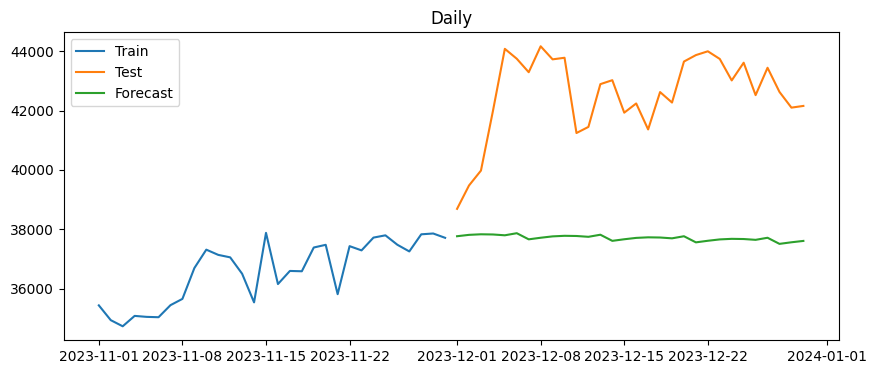

RMSE: 5040
MAE: 4847
MAPE: 11.3 %


In [13]:
# Forecast the last 30 days
daily_pred = model_daily.forecast(periods)

# Assess the model using the previously defined function
model_assessment(train.loc["2023-11"], test, daily_pred, "Daily")

## Exponential Smoothing & Holt Winters

In [14]:
df = pd.read_csv("Exponential Smoothing and Holt Winters/weekly_customer_complaints.csv", index_col="week", parse_dates=True)
df.head()

,complaints,discount_rate,small_commercial_event,medium_commercial_event,big_commercial_event
week,,,,,
2018-01-01,"1,750",37.26%,1,0,0
2018-01-08,"1,701",35.38%,0,0,0
2018-01-15,"1,711",36.22%,1,0,0
2018-01-22,"1,443",38.33%,1,0,0
2018-01-29,"1,397",36.34%,0,0,0


In [15]:
# Rename the "complaints" column to "y" for convenience
df = df.rename(columns={"complaints": "y"})
df.head()

,y,discount_rate,small_commercial_event,medium_commercial_event,big_commercial_event
week,,,,,
2018-01-01,"1,750",37.26%,1,0,0
2018-01-08,"1,701",35.38%,0,0,0
2018-01-15,"1,711",36.22%,1,0,0
2018-01-22,"1,443",38.33%,1,0,0
2018-01-29,"1,397",36.34%,0,0,0


In [16]:
# get information for the dataframe 
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 261 entries, 2018-01-01 to 2022-12-26
Data columns (total 5 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   y                        261 non-null    object
 1   discount_rate            261 non-null    object
 2   small_commercial_event   261 non-null    int64 
 3   medium_commercial_event  261 non-null    int64 
 4   big_commercial_event     261 non-null    int64 
dtypes: int64(3), object(2)
memory usage: 12.2+ KB


In [17]:
# Remove commas from the "y" column and convert it to integer type
df["y"] = df["y"].str.replace(",", "").astype(int)
df.head()

,y,discount_rate,small_commercial_event,medium_commercial_event,big_commercial_event
week,,,,,
2018-01-01,1750,37.26%,1,0,0
2018-01-08,1701,35.38%,0,0,0
2018-01-15,1711,36.22%,1,0,0
2018-01-22,1443,38.33%,1,0,0
2018-01-29,1397,36.34%,0,0,0


### Data Visualization

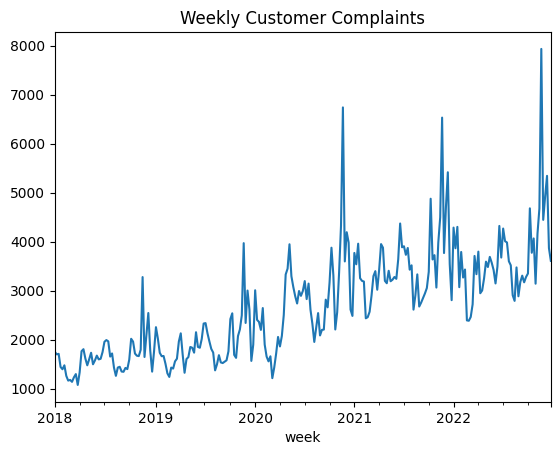

In [18]:
# basic type of time series data plot
df["y"].plot(title="Weekly Customer Complaints")
plt.show()

### Seasonality

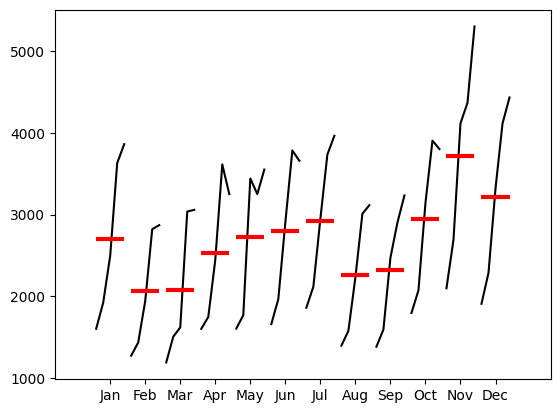

In [19]:
# Resample the data monthly (month-end) and plot each month separately to observe patterns
month_plot(df['y'].resample('ME').mean())
plt.show()

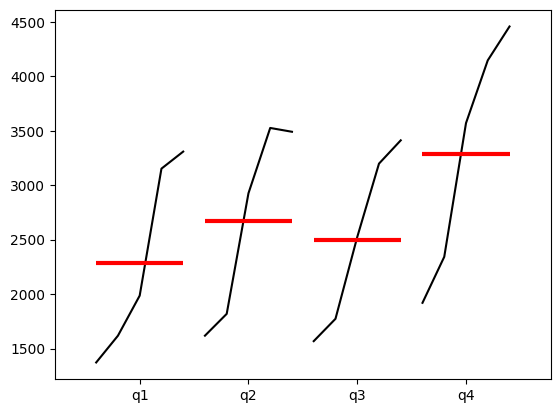

In [20]:
# Resample quarterly (quarter-end) and plot to see the quarterly seasonality
quarter_plot(df['y'].resample('QE').mean())
plt.show()

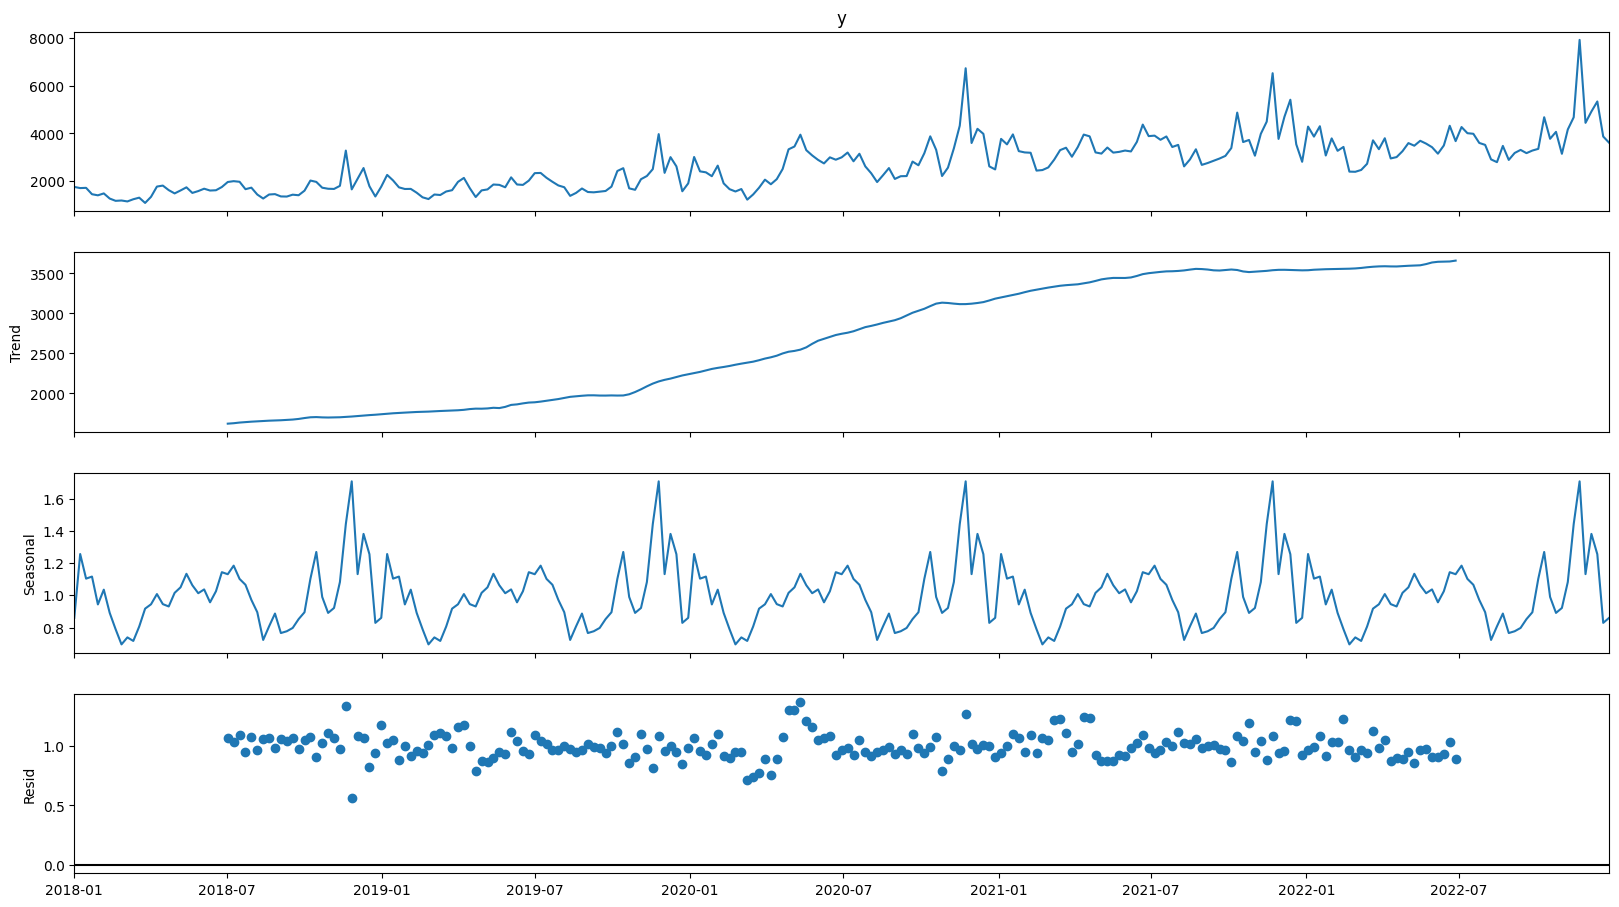

In [21]:
# Decompose the time series into trend, seasonality, and residual.
# We assume a yearly period of 52 weeks for weekly data.
decomposition = seasonal_decompose(df['y'],
                                   model='multiplicative',
                                   period=52)
fig = decomposition.plot()
fig.set_size_inches(18, 10)
plt.show()

### Patial Auto Correlation

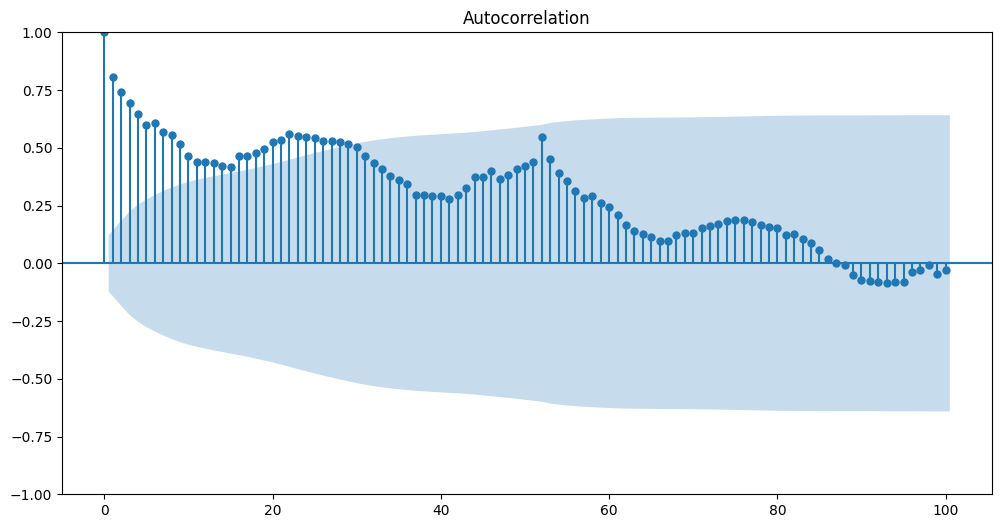

In [22]:
# ACF plot to see correlation of the series with lagged values
fig, ax = plt.subplots(figsize=(12, 6))
plot_acf(df['y'], lags=100, ax=ax)
plt.show() 

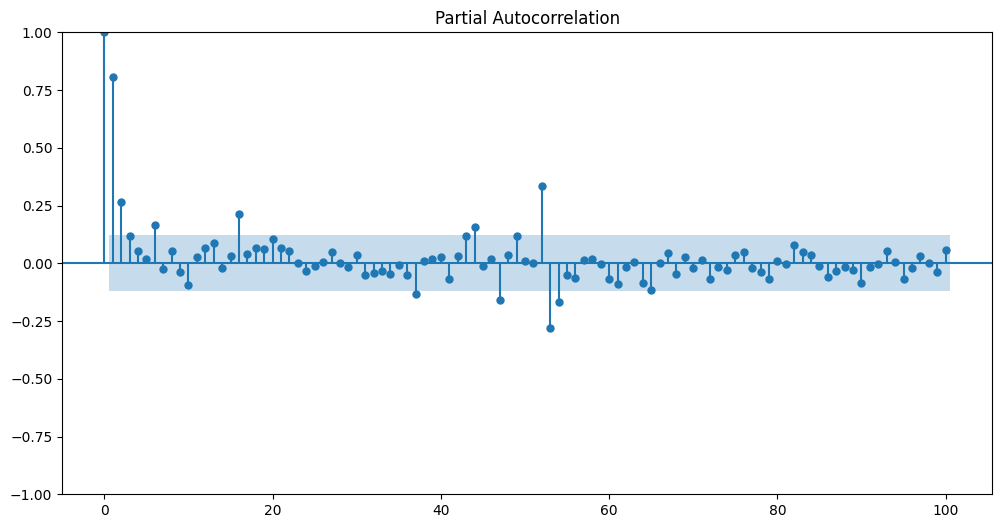

In [23]:
# PACF plot to see partial correlation (effect after removing intermediate lags)
fig, ax = plt.subplots(figsize=(12, 6))
plot_pacf(df['y'], lags=100, ax=ax)
plt.show()

### SETTING TIME SERIES FREQUENCY

In [24]:
# Inspect the DateTimeIndex
df.index

DatetimeIndex(['2018-01-01', '2018-01-08', '2018-01-15', '2018-01-22',
               '2018-01-29', '2018-02-05', '2018-02-12', '2018-02-19',
               '2018-02-26', '2018-03-05',
               ...
               '2022-10-24', '2022-10-31', '2022-11-07', '2022-11-14',
               '2022-11-21', '2022-11-28', '2022-12-05', '2022-12-12',
               '2022-12-19', '2022-12-26'],
              dtype='datetime64[ns]', name='week', length=261, freq=None)

In [25]:
# Convert the DataFrame to have weekly frequency (Mon-based).
df = df.asfreq('W-MON')
df.index

DatetimeIndex(['2018-01-01', '2018-01-08', '2018-01-15', '2018-01-22',
               '2018-01-29', '2018-02-05', '2018-02-12', '2018-02-19',
               '2018-02-26', '2018-03-05',
               ...
               '2022-10-24', '2022-10-31', '2022-11-07', '2022-11-14',
               '2022-11-21', '2022-11-28', '2022-12-05', '2022-12-12',
               '2022-12-19', '2022-12-26'],
              dtype='datetime64[ns]', name='week', length=261, freq='W-MON')

## Training and Testing

## GOAL 1: Predict the next 12 weeks

In [26]:
# We want to forecast the next 12 weeks
periods = 12

# Splitting data into train (all but last 12 weeks) and test (last 12 weeks)
# train = df[:-periods].y
# test = df[-periods:].y
# Other way to split data
train, test = df.iloc[:-periods, 0], df.iloc[-periods:, 0]

### Simple Exponential Smoothing

In [27]:
# Fit a Simple Exponential Smoothing model on the training set
ses_model = SimpleExpSmoothing(train).fit()
print(ses_model.summary())

                       SimpleExpSmoothing Model Results                       
Dep. Variable:                      y   No. Observations:                  249
Model:             SimpleExpSmoothing   SSE                       74368321.050
Optimized:                       True   AIC                           3143.165
Trend:                           None   BIC                           3150.200
Seasonal:                        None   AICC                          3143.329
Seasonal Periods:                None   Date:                 Tue, 16 Sep 2025
Box-Cox:                        False   Time:                         11:04:55
Box-Cox Coeff.:                  None                                         
                       coeff                 code              optimized      
------------------------------------------------------------------------------
smoothing_level            0.5099783                alpha                 True
initial_level              1750.0000                

In [28]:
# Just a quick demonstration: check the last train value scaled (not used in final steps)
train.iloc[-1] * 0.50 + 1750

3425.0

In [29]:
# Forecast the next 12 weeks using the fitted model
ses_pred = ses_model.forecast(periods)
ses_pred

2022-10-10    3294.472148
2022-10-17    3294.472148
2022-10-24    3294.472148
2022-10-31    3294.472148
2022-11-07    3294.472148
2022-11-14    3294.472148
2022-11-21    3294.472148
2022-11-28    3294.472148
2022-12-05    3294.472148
2022-12-12    3294.472148
2022-12-19    3294.472148
2022-12-26    3294.472148
Freq: W-MON, dtype: float64

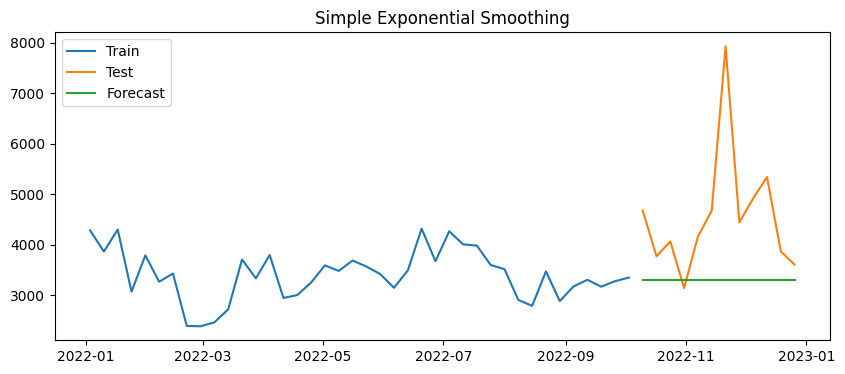

In [30]:
# Set the size of the plot of 10 by 4
plt.figure(figsize = (10, 4))

# Plot the train, test and forecast data
plt.plot(train.loc['2022'], label = "Train")
plt.plot(test, label = "Test")
plt.plot(ses_pred, label = "Forecast")

# Add a title and legend to the plot
plt.title("Simple Exponential Smoothing")
plt.legend()
plt.show()

### Double Exponential Smoothing

In [31]:
# Build a double exponential smoothing model (trend="add" for additive trend)
model_double = ExponentialSmoothing(
    endog=train,
    trend="add",
    seasonal=None
).fit()
print(model_double.summary())

                       ExponentialSmoothing Model Results                       
Dep. Variable:                        y   No. Observations:                  249
Model:             ExponentialSmoothing   SSE                       74354284.690
Optimized:                         True   AIC                           3147.118
Trend:                         Additive   BIC                           3161.188
Seasonal:                          None   AICC                          3147.465
Seasonal Periods:                  None   Date:                 Tue, 16 Sep 2025
Box-Cox:                          False   Time:                         11:04:58
Box-Cox Coeff.:                    None                                         
                       coeff                 code              optimized      
------------------------------------------------------------------------------
smoothing_level            0.5095210                alpha                 True
smoothing_trend             0.0000

In [32]:
# Forecast with the double ES model
double_pred = model_double.forecast(periods)
double_pred

2022-10-10    3306.364250
2022-10-17    3312.461219
2022-10-24    3318.558187
2022-10-31    3324.655155
2022-11-07    3330.752124
2022-11-14    3336.849092
2022-11-21    3342.946061
2022-11-28    3349.043029
2022-12-05    3355.139997
2022-12-12    3361.236966
2022-12-19    3367.333934
2022-12-26    3373.430902
Freq: W-MON, dtype: float64

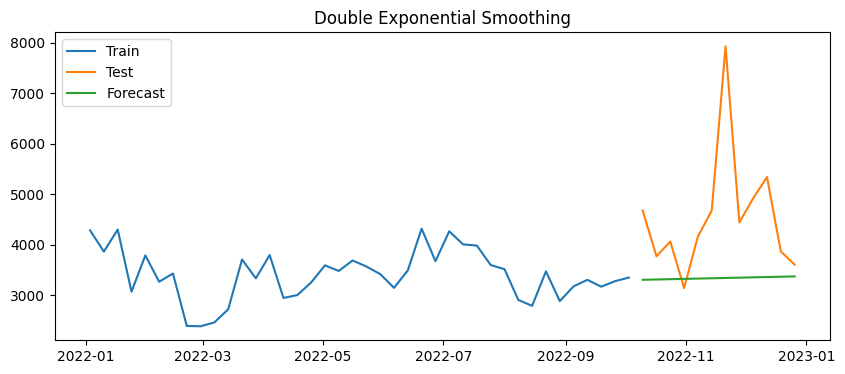

In [33]:
# Plot the train, test and forecast
plt.figure(figsize = (10, 4))

# Plot the train, test and forecast data
plt.plot(train.loc['2022'], label = "Train")
plt.plot(test, label = "Test")
plt.plot(double_pred, label = "Forecast")

# Add a title and legend to the plot
plt.title("Double Exponential Smoothing")
plt.legend()
plt.show()

### Holt Winter aka Tripe Exponential Smoothing

In [34]:
# Build the Holt-Winters model with both trend and seasonality
# Using seasonal_periods=52 for weekly data, with a multiplicative season
model_holt = ExponentialSmoothing(
    endog=train,
    trend="add",
    seasonal="mul",
    seasonal_periods=52
).fit()
#print(model_holt.summary())

In [35]:
# Forecast the next 12 weeks
holt_pred = model_holt.forecast(periods)
holt_pred[:5]

2022-10-10    4820.334570
2022-10-17    3761.448122
2022-10-24    3379.316919
2022-10-31    3294.355283
2022-11-07    4078.805470
Freq: W-MON, dtype: float64

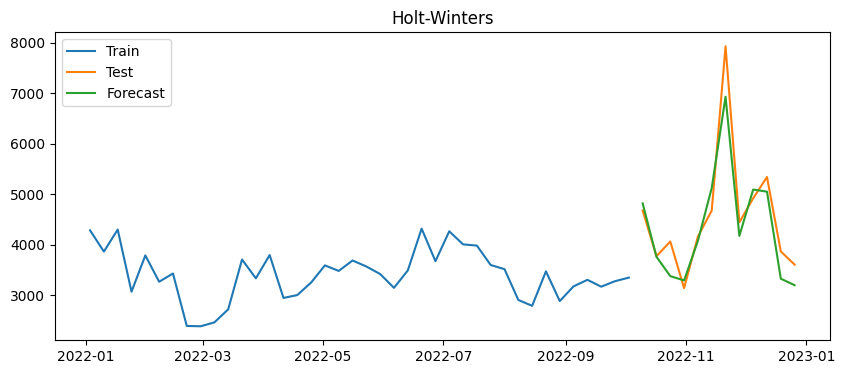

In [36]:
# Plot the Train, Test and Forecast
plt.figure(figsize = (10, 4))

# Plot the train, test and forecast
plt.plot(train.loc['2022'], label = "Train")
plt.plot(test, label = "Test")
plt.plot(holt_pred, label = "Forecast")

# Add a title and legend to the plot
plt.title("Holt-Winters")
plt.legend()
plt.show()

In [37]:
# Evaluate the forecast using RMSE, MAE, MAPE
rmse = root_mean_squared_error(test, holt_pred)
mae = mean_absolute_error(test, holt_pred)
mape = mean_absolute_percentage_error(test, holt_pred)
print(f"RMSE: {rmse:.0f}")
print(f"MAE: {mae:.0f}")
print(f"MAPE: {100 * mape:.1f} %")

RMSE: 444
MAE: 350
MAPE: 7.5 %


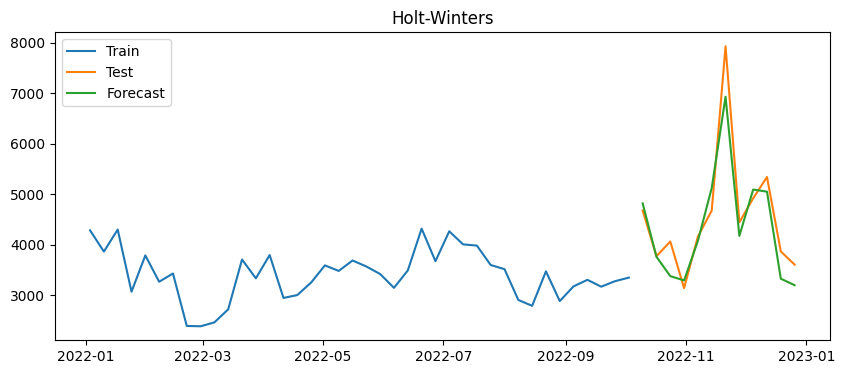

RMSE: 444
MAE: 350
MAPE: 7.5 %


In [38]:
model_assessment(train.loc['2022'], test, holt_pred, "Holt-Winters")

## Predict the future

In [39]:
df.head()

,y,discount_rate,small_commercial_event,medium_commercial_event,big_commercial_event
week,,,,,
2018-01-01,1750,37.26%,1,0,0
2018-01-08,1701,35.38%,0,0,0
2018-01-15,1711,36.22%,1,0,0
2018-01-22,1443,38.33%,1,0,0
2018-01-29,1397,36.34%,0,0,0


In [40]:
# Build a Holt-Winters model using the complete dataset
model_holt_complete = ExponentialSmoothing(
    endog=df.y,
    trend="add",
    seasonal="mul",
    seasonal_periods=52
).fit()

In [41]:
# Forecast the next 13 weeks beyond the existing data
forecast = model_holt_complete.forecast(periods)
forecast[:5]

2023-01-02    4965.823442
2023-01-09    4478.080387
2023-01-16    4699.504239
2023-01-23    3814.115587
2023-01-30    4242.017850
Freq: W-MON, dtype: float64

In [42]:
def plot_future(y, forecast, chart_title = None):
  """
  Plots the historical data and future forecasts on the same axis.
  """

  # Plot the training data and forecast
  plt.figure(figsize = (10, 4))

  # Plot the train, test and forecast
  plt.plot(y, label = "Train")
  plt.plot(forecast, label = "Forecast")

  # Add a title and legend to the plot
  plt.title(chart_title)
  plt.legend()
  plt.show()

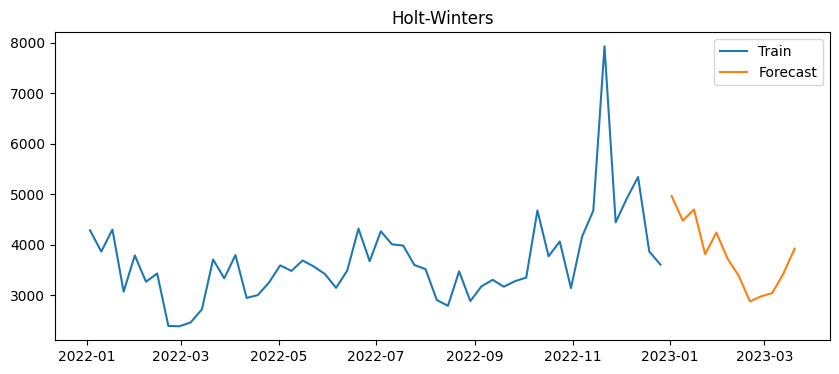

In [43]:
# Apply the function
plot_future(df.y.loc["2022"], forecast, "Holt-Winters")

# Project2: Air Miles use Holt Winters 

### Airmiles Data Read Dataset 

In [44]:
df_airmiles = pd.read_csv("CAPSTONE PROJECT - Airmiles/airmiles.csv", index_col = "Date", parse_dates = True, dayfirst = True)
df_airmiles.head()

,airmiles
Date,
1996-01-01,30983174
1996-02-01,32147663
1996-03-01,38342975
1996-04-01,35969113
1996-05-01,36474391


In [45]:
df_airmiles.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 113 entries, 1996-01-01 to 2005-05-01
Data columns (total 1 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   airmiles  113 non-null    int64
dtypes: int64(1)
memory usage: 1.8 KB


In [46]:
df_airmiles = df_airmiles.asfreq("MS")
df_airmiles.index

DatetimeIndex(['1996-01-01', '1996-02-01', '1996-03-01', '1996-04-01',
               '1996-05-01', '1996-06-01', '1996-07-01', '1996-08-01',
               '1996-09-01', '1996-10-01',
               ...
               '2004-08-01', '2004-09-01', '2004-10-01', '2004-11-01',
               '2004-12-01', '2005-01-01', '2005-02-01', '2005-03-01',
               '2005-04-01', '2005-05-01'],
              dtype='datetime64[ns]', name='Date', length=113, freq='MS')

In [47]:
df_airmiles = df_airmiles.rename(columns={'airmiles' : 'y'})
df_airmiles.head()

,y
Date,
1996-01-01,30983174
1996-02-01,32147663
1996-03-01,38342975
1996-04-01,35969113
1996-05-01,36474391


### Airmiles Data Visualization

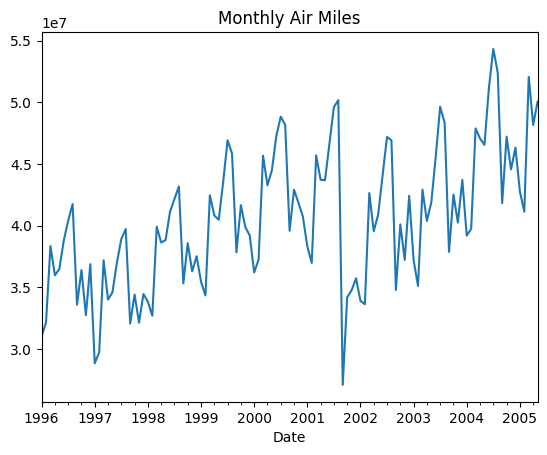

In [48]:
# basic type of time series data plot
df_airmiles["y"].plot(title="Monthly Air Miles")
plt.show()

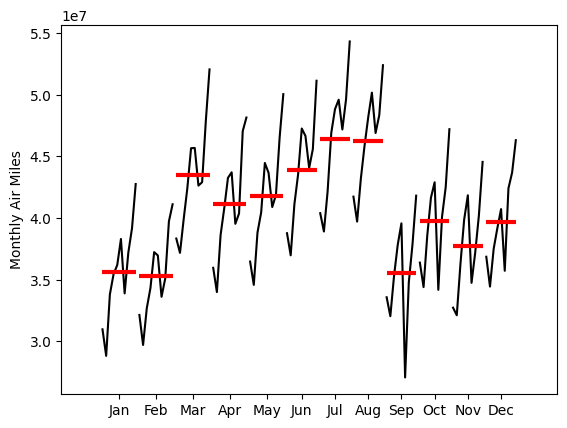

In [49]:
# month_plot() - To visualize the average value for each month across multiple years in a time series
# red lines - Represents the mean value for each month

# Plotting the monthly seasonality of Air Miles
month_plot(df_airmiles['y'], ylabel = 'Monthly Air Miles')
plt.show()

/var/folders/xv/4vnw6yfn5751z9qygvp6480h0000gn/T/ipykernel_1551/3694392037.py:5: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  quarter_plot(df_airmiles['y'].resample('Q').mean(), ylabel = 'Monthly Air Miles')


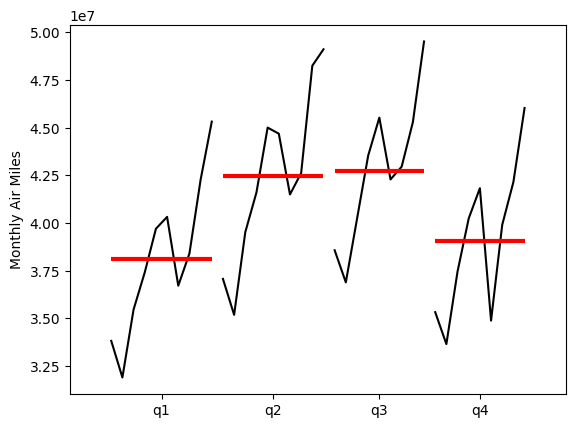

In [50]:
# quarter_plot() - To visualize seasonal patterns at a quarterly level.
# Q1 (january, february, march), Q2 (april, may, june), Q3 (july, august, september), Q4 (october, november, december)

# Plotting the quarterly seasonality of Air Miles
quarter_plot(df_airmiles['y'].resample('Q').mean(), ylabel = 'Monthly Air Miles')
plt.show()

`seasonal_decompose` - To decompose a time series into its constituent parts to better understand the underlying patterns.

components

- Trend: The overall direction of the series (increasing, decreasing, or stable).
- Seasonal: Repeating patterns at fixed intervals (e.g., daily, weekly, monthly).
- Residual: The remaining variation after removing trend and seasonal components.

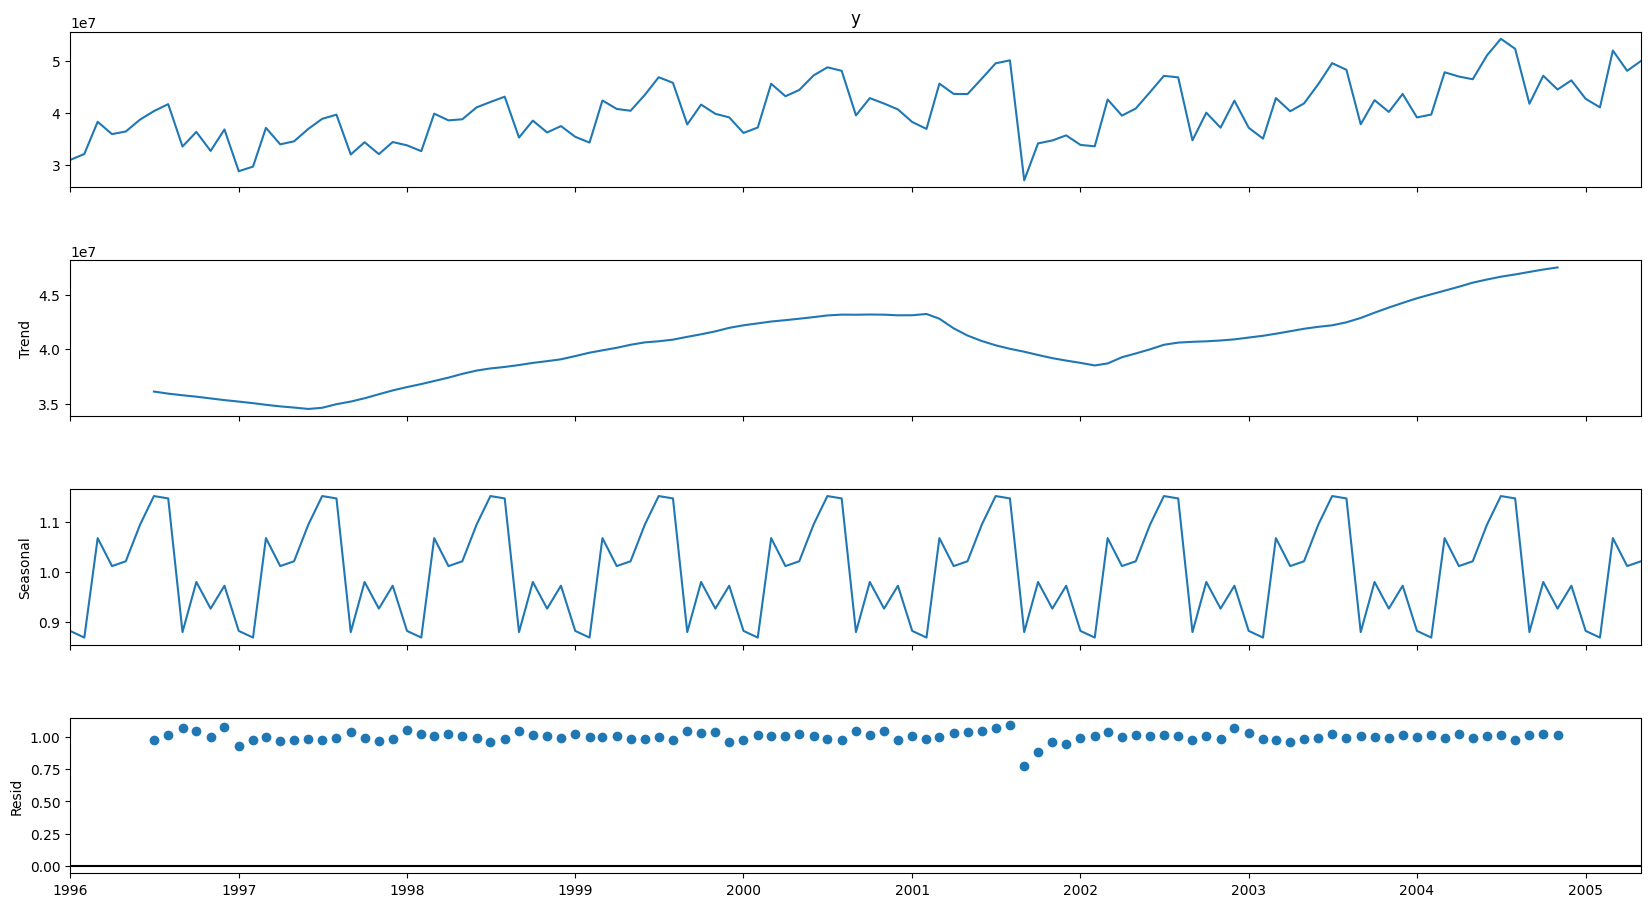

In [51]:
decomposition = seasonal_decompose(df_airmiles['y'],
                                   model='multiplicative',
                                   period=12)
fig = decomposition.plot()
fig.set_size_inches(18, 10)
plt.show()

Autocorrelation measures the correlation between a time series and a lagged version of itself.

Purpose: To identify patterns or repeating cycles in a time series dataset.

Interpretation:

Values range from -1 to 1.
1 indicates perfect positive correlation.
-1 indicates perfect negative correlation.
0 indicates no correlation.
ACF Plot:

X-axis: Lag periods
Y-axis: Correlation coefficient
Key Features:

At lag 0, autocorrelation is always 1 (a series is perfectly correlated with itself).
Significant spikes at certain lags indicate repeating patterns.

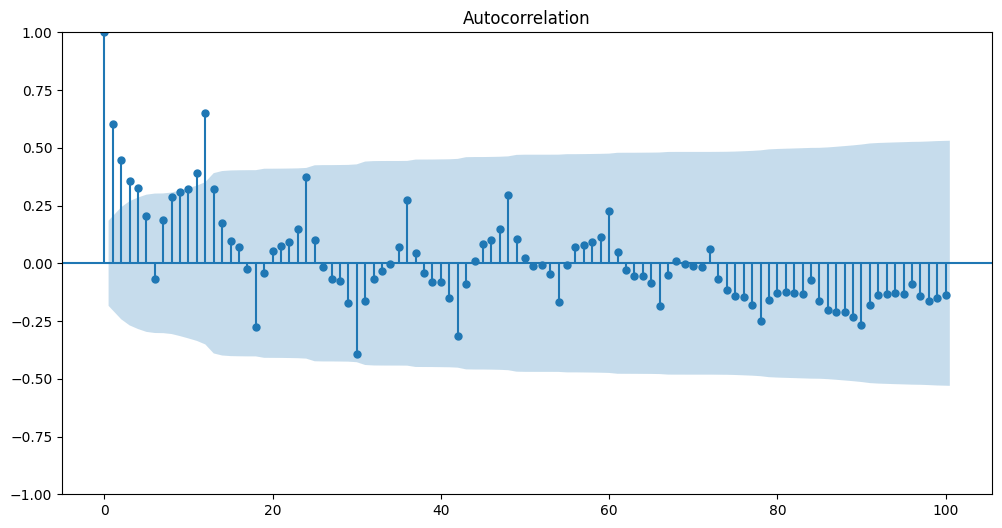

In [52]:
# Plot the autocorrelation (ACF) of air miles values
fig, ax = plt.subplots(figsize = (12,6))
plot_acf(df_airmiles['y'], lags = 100, ax = ax)
plt.show()

PACF measures the correlation between a time series and its lag, after removing the effects of all shorter lags.

Purpose: To identify the direct relationship between an observation and its lag, without intermediate effects.

Main Difference between ACF and PACF:

ACF: Measures overall correlation at each lag, including indirect effects.
PACF: Measures direct correlation at each lag, excluding indirect effects.

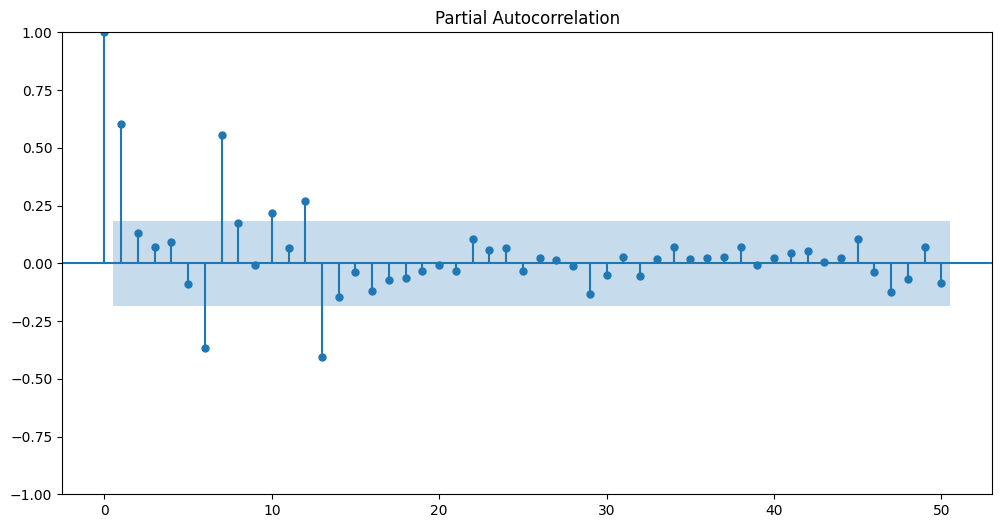

In [53]:
# PACF plot to see partial correlation (effect after removing intermediate lags)
fig, ax = plt.subplots(figsize=(12, 6))
plot_pacf(df_airmiles['y'], lags=50, ax=ax)
plt.show()

### Airmiles Data Predict Next 12 weeks 

In [54]:
# Train and test split
# using the last 12 weeks as test data
train, test = df_airmiles.iloc[:-12, :], df_airmiles.iloc[-12:, :]
test

,y
Date,
2004-06-01,51134050
2004-07-01,54317314
2004-08-01,52392985
2004-09-01,41816777
2004-10-01,47205665
2004-11-01,44553653
2004-12-01,46316602
2005-01-01,42760657
2005-02-01,41120838


In [55]:
# Holt - Winters Model
# Fit an Exponential Smoothing model to the training data
# Use multiplicative trend and multiplicative seasonal components with a seasonal period of 12 months
model = ExponentialSmoothing(train,
                             trend = 'mul',
                             seasonal = 'mul',
                             seasonal_periods = 12).fit()

# Forecast future values for the length of the test set
predictions = model.forecast(steps = len(test)).rename("Holt-Winters")
predictions

2004-06-01    5.008193e+07
2004-07-01    5.296881e+07
2004-08-01    5.297759e+07
2004-09-01    4.026246e+07
2004-10-01    4.514113e+07
2004-11-01    4.288743e+07
2004-12-01    4.506048e+07
2005-01-01    4.099020e+07
2005-02-01    4.067543e+07
2005-03-01    4.995164e+07
2005-04-01    4.748806e+07
2005-05-01    4.804790e+07
Freq: MS, Name: Holt-Winters, dtype: float64

### Airmile Data Model Assessment

In [56]:
# Function to assess model and visualize output
def model_assessment(train, test, predictions, chart_title):
  # Plot training, test, and forecasts
  plt.figure(figsize = (10,4))
  plt.plot(train, label = 'Train')
  plt.plot(test, label = 'Test')
  plt.plot(predictions, label = "Forecast")
  plt.title(f"Train, Test and Predictions with {chart_title}")
  plt.legend()
  plt.show()

  # Calculating the MAE, RMSE, and MAPE
  mae = mean_absolute_error(test, predictions)
  rmse = root_mean_squared_error(test, predictions)
  mape = mean_absolute_percentage_error(test, predictions)

  # print the metrics value
  print(f"The MAE is {mae:.2f}")
  print(f"The RMSE is {rmse:.2f}")
  print(f"The MAPE is {100 * mape:.2f} %")

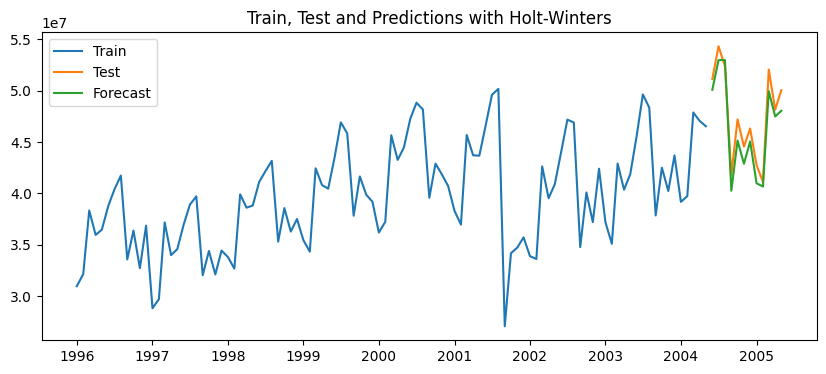

The MAE is 1375687.06
The RMSE is 1485766.79
The MAPE is 2.90 %


In [57]:
model_assessment(train, test, predictions, "Holt-Winters")

### Airmiles Data Predict Future

In [58]:
# Holt - Winters Model
# Fit an Exponential Smoothing model to the training data
# Use multiplicative trend and multiplicative seasonal components with a seasonal period of 12 months
model = ExponentialSmoothing(df_airmiles['y'], 
                             trend = 'mul',
                             seasonal = 'mul',
                             seasonal_periods = 12).fit()

# Forecast future values for the next 12 steps (months in this case)
predictions = model.forecast(steps = 12).rename("Holt-Winters")
predictions

2005-06-01    5.333950e+07
2005-07-01    5.645169e+07
2005-08-01    5.616236e+07
2005-09-01    4.298744e+07
2005-10-01    4.825182e+07
2005-11-01    4.579835e+07
2005-12-01    4.804129e+07
2006-01-01    4.379654e+07
2006-02-01    4.327073e+07
2006-03-01    5.336324e+07
2006-04-01    5.053892e+07
2006-05-01    5.132617e+07
Freq: MS, Name: Holt-Winters, dtype: float64

In [59]:
# Function to plot the future
def plot_future(y, forecast, title):
  # Plot training and forecasts
  plt.figure(figsize = (10,4))
  plt.plot(y, label = 'Train')
  plt.plot(forecast, label = "Forecast")
  plt.title(f"Train and Forecast with {title}")
  plt.legend()
  plt.show()

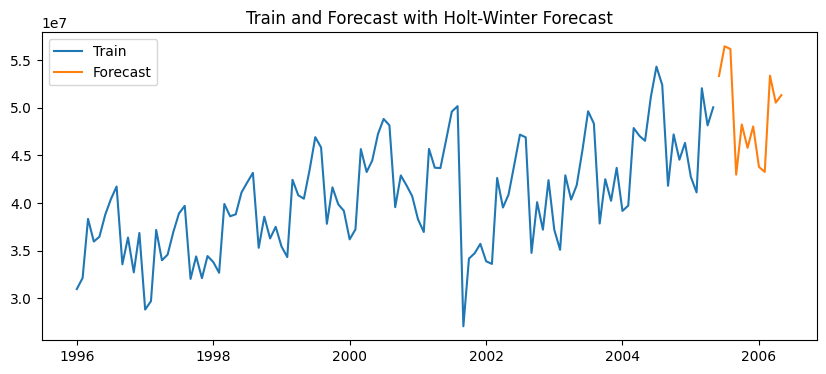

In [60]:
# Plot the train and forecast data
plot_future(df_airmiles['y'], predictions, 'Holt-Winter Forecast')

## Project3: ARIMA, SARIMA and SARIMAX

In [61]:
# ARIMA, SARIMA and SARIMAX/
# Loading the daily revenue data and set the date as uindex
df_revenue = pd.read_csv("ARIMA, SARIMA and SARIMAX/daily_revenue.csv")
df_revenue.head()

,date,revenue,discount_rate,coupon_rate
0,1/1/2018,"6,270,839",34.27%,1.09%
1,2/1/2018,"8,922,076",30.87%,1.08%
2,3/1/2018,"8,446,101",28.11%,1.01%
3,4/1/2018,"7,785,798",27.32%,0.96%
4,5/1/2018,"6,375,303",25.70%,0.90%


In [62]:
df_revenue = pd.read_csv("ARIMA, SARIMA and SARIMAX/daily_revenue.csv", index_col='date', parse_dates=True, dayfirst=True)
df_revenue.head()

,revenue,discount_rate,coupon_rate
date,,,
2018-01-01,"6,270,839",34.27%,1.09%
2018-01-02,"8,922,076",30.87%,1.08%
2018-01-03,"8,446,101",28.11%,1.01%
2018-01-04,"7,785,798",27.32%,0.96%
2018-01-05,"6,375,303",25.70%,0.90%


In [63]:
df_revenue.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1795 entries, 2018-01-01 to 2022-11-30
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   revenue        1795 non-null   object
 1   discount_rate  1795 non-null   object
 2   coupon_rate    1795 non-null   object
dtypes: object(3)
memory usage: 56.1+ KB


In [64]:
# Remove commas from the "y" column and convert it to integer type
df_revenue["revenue"] = df_revenue["revenue"].str.replace(",", "").astype(float)
df_revenue.head()

,revenue,discount_rate,coupon_rate
date,,,
2018-01-01,6270839.0,34.27%,1.09%
2018-01-02,8922076.0,30.87%,1.08%
2018-01-03,8446101.0,28.11%,1.01%
2018-01-04,7785798.0,27.32%,0.96%
2018-01-05,6375303.0,25.70%,0.90%


In [65]:
# Set the dataframe to have daily frequency
df_revenue = df_revenue.asfreq("D")

In [66]:
df_revenue = df_revenue.rename(columns = {'revenue': 'y'})
df_revenue.head()

,y,discount_rate,coupon_rate
date,,,
2018-01-01,6270839.0,34.27%,1.09%
2018-01-02,8922076.0,30.87%,1.08%
2018-01-03,8446101.0,28.11%,1.01%
2018-01-04,7785798.0,27.32%,0.96%
2018-01-05,6375303.0,25.70%,0.90%


### Revenue Data Visualization

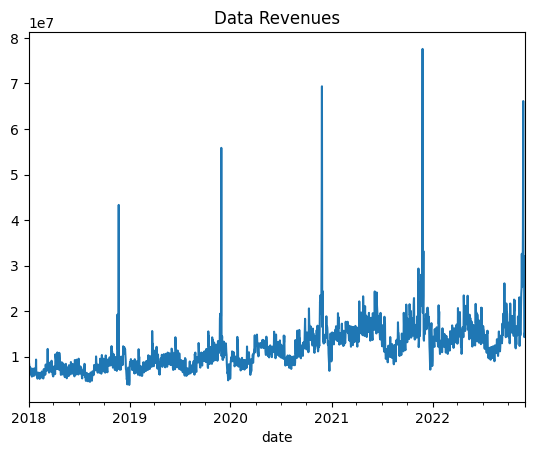

In [67]:
df_revenue['y'].plot(title = "Data Revenues")
plt.show()

/var/folders/xv/4vnw6yfn5751z9qygvp6480h0000gn/T/ipykernel_1551/2132562361.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  month_plot(df_revenue['y'].resample('M').mean(),


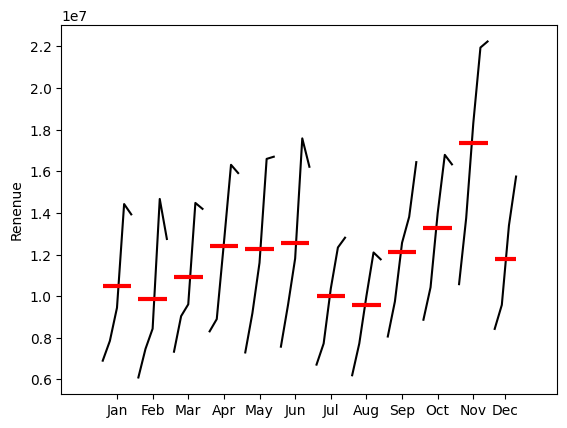

In [68]:
# monthly plot for the autocorelation 
month_plot(df_revenue['y'].resample('M').mean(), 
           ylabel='Renenue')
plt.show()

/var/folders/xv/4vnw6yfn5751z9qygvp6480h0000gn/T/ipykernel_1551/367949579.py:1: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  quarter_plot(df_revenue['y'].resample('Q').mean(),


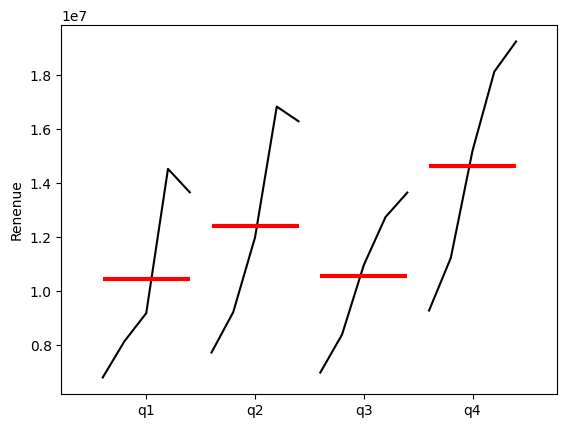

In [69]:
quarter_plot(df_revenue['y'].resample('Q').mean(), 
           ylabel='Renenue')
plt.show()

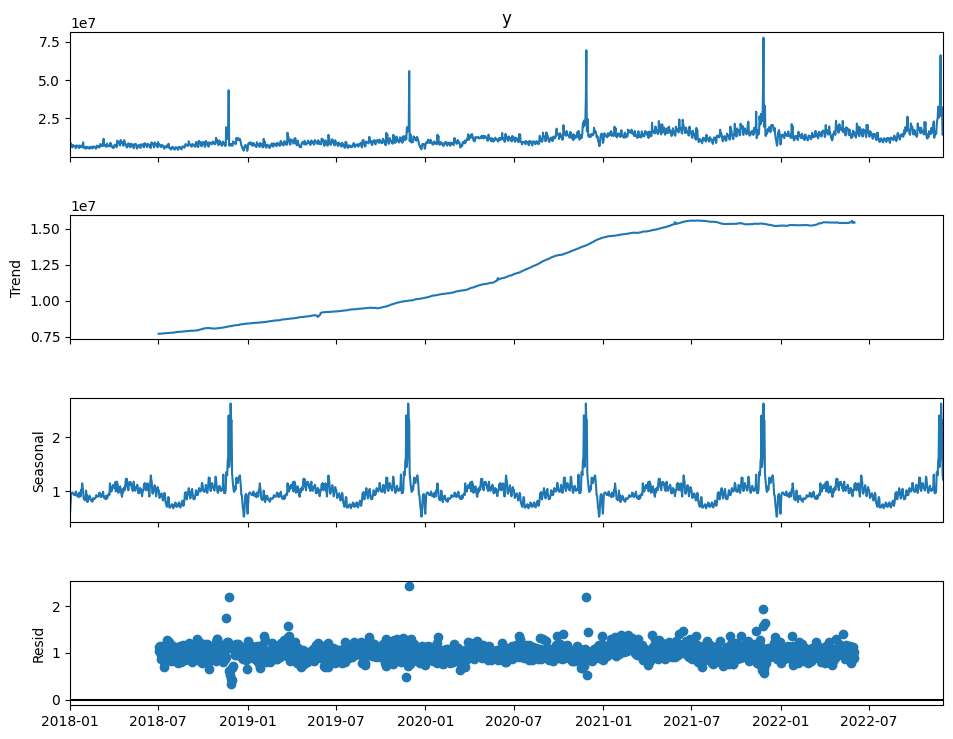

In [70]:
# Seasonal Decomposition Plots for Revenue Data
# Multiplicative model type, with daily seasonality (365 days)
decomposition = seasonal_decompose(df_revenue['y'],
                                   model = 'mul',
                                   period = 365)
fig = decomposition.plot()
fig.set_size_inches(10,8)
plt.show()

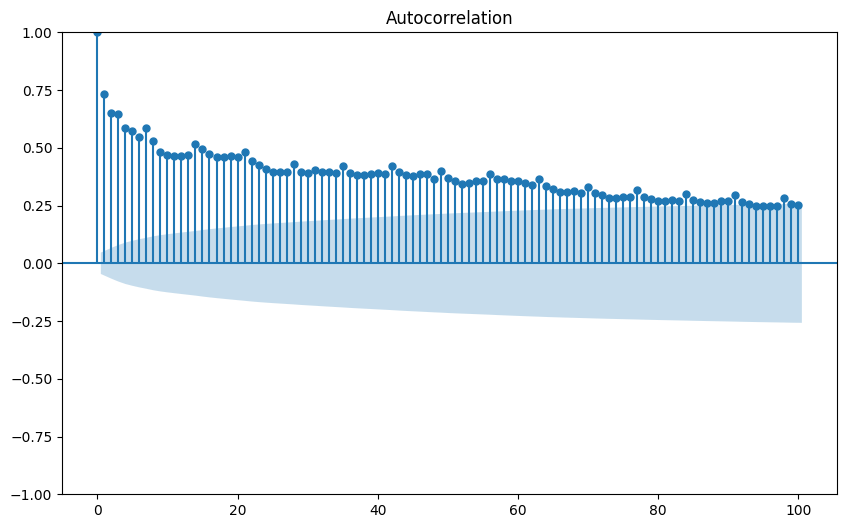

In [71]:
# Plot the autocorrelation (ACF) of revenue values
fig, ax = plt.subplots(figsize = (10,6))
plot_acf(df_revenue['y'], lags = 100, ax = ax)
plt.show()

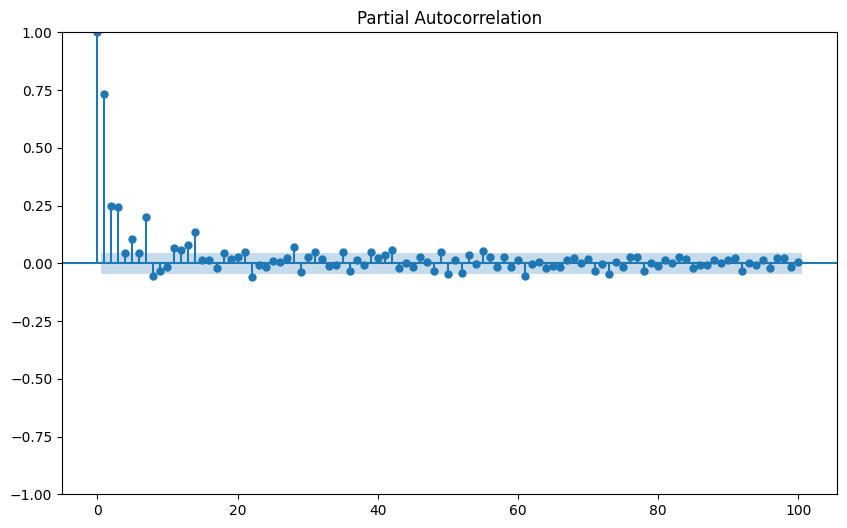

In [72]:
# Plot the autocorrelation (ACF) of revenue values
fig, ax = plt.subplots(figsize = (10,6))
plot_pacf(df_revenue['y'], lags = 100, ax = ax)
plt.show()

### Stationarity

In [73]:
from statsmodels.tsa.stattools import adfuller

In [74]:
# Perform Augmented Dickey-Fuller test
# 'result' contains the test statistic and the p-value.
result = adfuller(df_revenue.y)
print('p-value: %f' % result[1])

# Interpreting the results
if result[1] < 0.05:
    print("Evidence suggests that the time series is stationary.")
else:
    print("Evidence suggests that the time series is not stationary.")

p-value: 0.101904
Evidence suggests that the time series is not stationary.


In [75]:
# Compute the first difference of the 'y' column in DataFrame 'df' and assign it to a new column 'y_diff'.
# '.diff()' calculates the difference between consecutive elements along the specified axis (by default axis 0).
# 'dropna()' removes any rows with NaN values resulting from differencing.
df_revenue['y_diff'] = df_revenue.y.diff().dropna()
df_revenue['y_diff']

date
2018-01-01           NaN
2018-01-02     2651237.0
2018-01-03     -475975.0
2018-01-04     -660303.0
2018-01-05    -1410495.0
                 ...    
2022-11-26   -39180777.0
2022-11-27     4955921.0
2022-11-28      210050.0
2022-11-29   -17786305.0
2022-11-30      712049.0
Freq: D, Name: y_diff, Length: 1795, dtype: float64

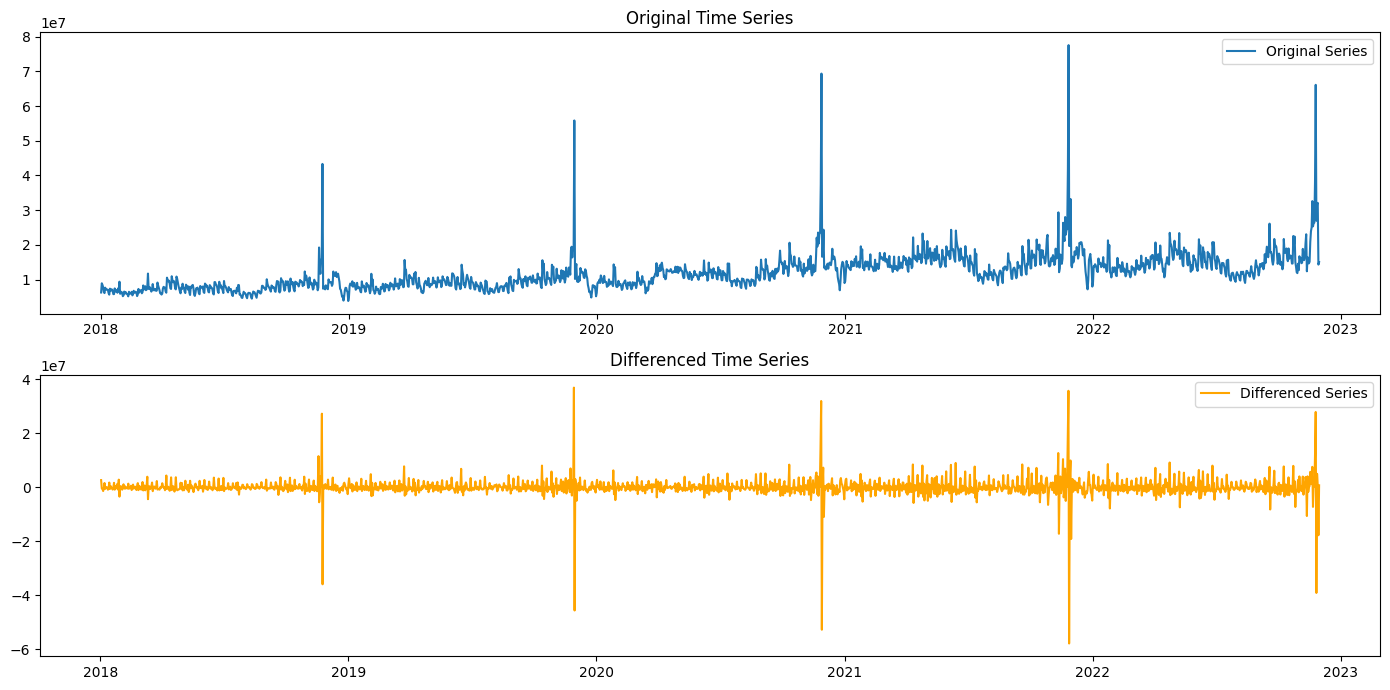

In [76]:
# Plotting the original and differenced series
# Set the size of the plot to 14 inches by 7 inches
plt.figure(figsize=(14, 7))

# Subplot for the original series
plt.subplot(2, 1, 1)  # 2 rows, 1 column, 1st subplot
plt.plot(df_revenue.y, label='Original Series')
plt.title('Original Time Series')
plt.legend()

# Subplot for the differenced series
plt.subplot(2, 1, 2)  # 2 rows, 1 column, 2nd subplot
plt.plot(df_revenue['y_diff'], label='Differenced Series', color='orange')
plt.title('Differenced Time Series')
plt.legend()

# Adjust layout to prevent overlapping of titles and labels
plt.tight_layout()
plt.show()

In [77]:
# Perform ADF test without null values
# 'result' contains the test statistic and the p-value.
result = adfuller(df_revenue['y_diff'].dropna())
print('p-value: %f' % result[1])

# Interpreting the results
if result[1] < 0.05:
    print("Evidence suggests that the time series is stationary.")
else:
    print("Evidence suggests that the time series is not stationary.")

p-value: 0.000000
Evidence suggests that the time series is stationary.


### ARIMA Model

In [78]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [79]:
# Split the Data into training and test
# Number of days to reserve for testing
test_days = 30 
train = df_revenue.iloc[:-test_days]
test = df_revenue.iloc[-test_days:]
test.head()

,y,discount_rate,coupon_rate,y_diff
date,,,,
2022-11-01,16703680.0,23.85%,1.50%,4014654.0
2022-11-02,15827022.0,20.76%,0.94%,-876658.0
2022-11-03,16154319.0,21.85%,0.92%,327297.0
2022-11-04,14707212.0,20.17%,0.88%,-1447107.0
2022-11-05,14877530.0,17.85%,0.41%,170318.0


In [80]:
model = SARIMAX(train['y'], order = (3, 1, 1), seasonal_order = (0,0,0,0)).fit() 
print(model.summary())

 This problem is unconstrained.


RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =            5     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  1.63668D+01    |proj g|=  4.37393D-02

At iterate    5    f=  1.63552D+01    |proj g|=  7.71775D-02

At iterate   10    f=  1.63349D+01    |proj g|=  1.44054D-02

At iterate   15    f=  1.63335D+01    |proj g|=  4.03235D-04

           * * *

Tit   = total number of iterations
Tnf   = total number of function evaluations
Tnint = total number of segments explored during Cauchy searches
Skip  = number of BFGS updates skipped
Nact  = number of active bounds at final generalized Cauchy point
Projg = norm of the final projected gradient
F     = final function value

           * * *

   N    Tit     Tnf  Tnint  Skip  Nact     Projg        F
    5     17     19      1     0     0   2.947D-06   1.633D+01
  F =   16.333514364611993     

CONVERGENCE: NORM_OF_PROJECTED_GRADIENT_<=_PGTOL            
        

In [87]:
model = auto_arima(train['y'], seasonal = False)

/Users/sanamjankurban/anaconda3/envs/my_env/lib/python3.10/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/sanamjankurban/anaconda3/envs/my_env/lib/python3.10/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/sanamjankurban/anaconda3/envs/my_env/lib/python3.10/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/sanamjankurban/anaconda3/envs/my_env/lib/python3.10/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/sanamjankurban/anaconda3/envs/my_env/lib/python3.10/site-packages/sklearn/utils/d

In [88]:
print(model.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 1765
Model:               SARIMAX(5, 1, 2)   Log Likelihood              -28817.267
Date:                Tue, 16 Sep 2025   AIC                          57650.535
Time:                        11:14:44   BIC                          57694.337
Sample:                    01-01-2018   HQIC                         57666.720
                         - 10-31-2022                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.4136      0.120     -3.449      0.001      -0.649      -0.179
ar.L2          0.3017      0.053      5.671      0.000       0.197       0.406
ar.L3          0.1570      0.028      5.705      0.0

In [89]:
#prediction the ARIMA model
predictions_arima = model.predict(n_periods = len(test))
predictions_arima

/Users/sanamjankurban/anaconda3/envs/my_env/lib/python3.10/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


2022-11-01    1.445299e+07
2022-11-02    1.474103e+07
2022-11-03    1.503283e+07
2022-11-04    1.527520e+07
2022-11-05    1.534078e+07
2022-11-06    1.553442e+07
2022-11-07    1.554542e+07
2022-11-08    1.563967e+07
2022-11-09    1.565016e+07
2022-11-10    1.569221e+07
2022-11-11    1.570256e+07
2022-11-12    1.571953e+07
2022-11-13    1.572734e+07
2022-11-14    1.573420e+07
2022-11-15    1.573904e+07
2022-11-16    1.574197e+07
2022-11-17    1.574462e+07
2022-11-18    1.574600e+07
2022-11-19    1.574734e+07
2022-11-20    1.574804e+07
2022-11-21    1.574869e+07
2022-11-22    1.574906e+07
2022-11-23    1.574937e+07
2022-11-24    1.574956e+07
2022-11-25    1.574971e+07
2022-11-26    1.574981e+07
2022-11-27    1.574988e+07
2022-11-28    1.574994e+07
2022-11-29    1.574997e+07
2022-11-30    1.575000e+07
Freq: D, dtype: float64

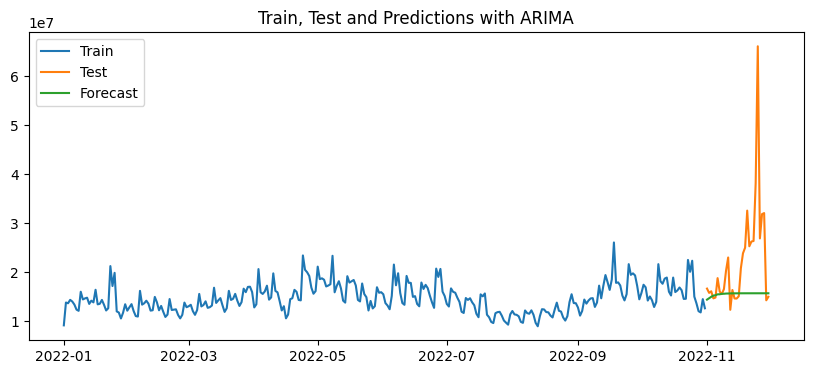

The MAE is 7267306.02
The RMSE is 12366038.30
The MAPE is 24.15 %


In [90]:
# Visualization the forecast and assess model
model_assessment(train['y']['2022':], test['y'], predictions_arima, "ARIMA")